### Install the required packages

In [20]:
%pip install -q langgraph langchain_openai langchain_huggingface

### Set up Environment

In [21]:
import os
from typing import TypedDict, List, Dict, Any, Optional
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# Set your OpenAI API key here
os.environ["OPENAI_API_KEY"] = ""  # Replace with your actual API key

# Initialize our LLM
model = ChatOpenAI(model="gpt-4o", temperature=0)

### Define State

In [22]:
class EmailState(TypedDict):
    email: Dict[str, Any]
    is_spam: Optional[bool]
    spam_reason: Optional[str]
    email_category: Optional[str]
    email_draft: Optional[str]
    messages: List[Dict[str, Any]]

### Define Nodes

In [23]:
def read_email(state: EmailState):
    email = state["email"]
    print(f"An AI Agent is processing an email from {email['sender']} with subject: {email['subject']}")
    return {}


def classify_email(state: EmailState):
    email = state["email"]

    prompt = f"""
As a professional email reader, analyze this email and determine if it is spam or legitimate and should be brought to Mala's attention.

Email:
From: {email['sender']}
Subject: {email['subject']}
Body: {email['body']}

First, determine if this email is spam.
answer with SPAM or HAM if it's legitimate. Only return the answer
Answer :
    """
    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)

    response_text = response.content.lower()
    print(response_text)

    is_spam = "spam" in response_text and "ham" not in response_text

    if not is_spam:
        new_messages = state.get("messages", []) + [
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": response.content}
        ]
    else:
        new_messages = state.get("messages", [])

    return {
        "is_spam": is_spam,
        "messages": new_messages
    }


def handle_spam(state: EmailState):
    print(f"Alfred has marked the email as spam.")
    print("The email has been moved to the spam folder.")
    return {}


def drafting_response(state: EmailState):
    email = state["email"]

    prompt = f"""
As an AI Agent, draft a polite preliminary response to this email.

Email:
From: {email['sender']}
Subject: {email['subject']}
Body: {email['body']}

Draft a brief, professional response that Mala can review and personalize before sending.
    """

    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)

    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]

    return {
        "email_draft": response.content,
        "messages": new_messages
    }


def notify_ms_mala(state: EmailState):
    email = state["email"]

    print("\n" + "=" * 50)
    print(f"Hello, I am your AI Agent. You have received an email from {email['sender']}.")
    print(f"Subject: {email['subject']}")
    print("\nI've prepared a draft response for your review:")
    print("-" * 50)
    print(state["email_draft"])
    print("=" * 50 + "\n")

    return {}


### Define routing logic

In [24]:
def route_email(state: EmailState) -> str:
    if state["is_spam"]:
        return "spam"
    else:
        return "legitimate"

### Create the graph

In [25]:
email_graph = StateGraph(EmailState)

### Add nodes

In [26]:
email_graph.add_node("read_email", read_email)
email_graph.add_node("classify_email", classify_email)
email_graph.add_node("handle_spam", handle_spam)
email_graph.add_node("drafting_response", drafting_response)
email_graph.add_node("notify_ms_mala", notify_ms_mala)

### Add edges

In [27]:
email_graph.add_edge(START, "read_email")

email_graph.add_edge("read_email", "classify_email")


### Add conditional edges

In [28]:
email_graph.add_conditional_edges(
    "classify_email",
    route_email,
    {
        "spam": "handle_spam",
        "legitimate": "drafting_response"
    }
)

### Add final edges

In [29]:
email_graph.add_edge("handle_spam", END)
email_graph.add_edge("drafting_response", "notify_ms_mala")
email_graph.add_edge("notify_ms_mala", END)

### Compile the graph

In [30]:
compiled_graph = email_graph.compile()

### Visualize the LangGraph workflow as a graph image

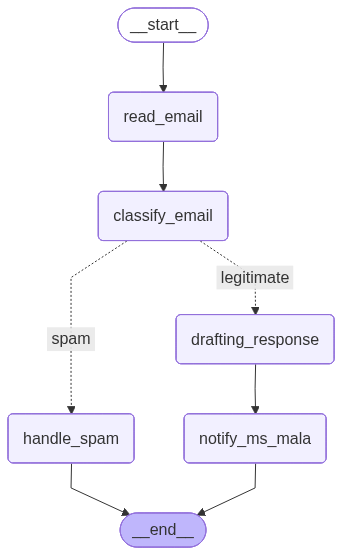

In [31]:
from IPython.display import Image, display

display(Image(compiled_graph.get_graph().draw_mermaid_png()))

 ### Example emails for testing - legitimate & spam emails

In [32]:
legitimate_email = {
    "sender": "LangChain",
    "subject": "Potential partnership ! ",
    "body": "We would like to explore a potential partnership/collaboration with Tech With Mala. Do let us know a good time to reach you!"
}

spam_email = {
    "sender": "Crypto bro",
    "subject": "The best investment of 2026",
    "body": "Ms Mala, I just launched an ALT coin and want you to buy some !"
}

### Process legitimate email

In [33]:
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke({
    "email": legitimate_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})


Processing legitimate email...
An AI Agent is processing an email from LangChain with subject: Potential partnership ! 
ham

Hello, I am your AI Agent. You have received an email from LangChain.
Subject: Potential partnership ! 

I've prepared a draft response for your review:
--------------------------------------------------
Subject: Re: Potential Partnership

Dear [Name],

Thank you for reaching out and considering a potential partnership with Tech With Mala. We are excited about the opportunity to explore how we can collaborate with LangChain.

Please let us know your availability for a meeting, and we will do our best to accommodate. We look forward to discussing this further.

Best regards,

Mala  
[Your Position]  
Tech With Mala  
[Your Contact Information]  



### Process spam email

In [34]:
print("\nProcessing spam email...")
spam_result = compiled_graph.invoke({
    "email": spam_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})


Processing spam email...
An AI Agent is processing an email from Crypto bro with subject: The best investment of 2026
spam
Alfred has marked the email as spam.
The email has been moved to the spam folder.


# Inspect Our Email Sorting Agent Using Langfuse

### Install Langfuse package

In [35]:
!pip install langfuse[langchain]

### Set the Langfuse API keys

In [36]:
import os

# Get keys for your project from the project settings page: https://cloud.langfuse.com
os.environ["LANGFUSE_PUBLIC_KEY"] = ""
os.environ["LANGFUSE_SECRET_KEY"] = ""
#os.environ["LANGFUSE_HOST"] = "https://cloud.langfuse.com"  # 🇪🇺 EU region
os.environ["LANGFUSE_HOST"] = "https://us.cloud.langfuse.com" # 🇺🇸 US region

### Configure the Langfuse CallbackHandler

In [37]:
from langfuse.langchain import CallbackHandler

# Initialize Langfuse CallbackHandler for LangGraph/Langchain (tracing)
langfuse_handler = CallbackHandler()

### add config to the invocation of the agents and run them again

In [38]:
# Process legitimate email
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke(
    input={
        "email": legitimate_email,
        "is_spam": None,
        "draft_response": None,
        "messages": []
    },
    config={"callbacks": [langfuse_handler]}
)

# Process spam email
print("\nProcessing spam email...")
spam_result = compiled_graph.invoke(
    input={
        "email": spam_email,
        "is_spam": None,
        "draft_response": None,
        "messages": []
    },
    config={"callbacks": [langfuse_handler]}
)


Processing legitimate email...
An AI Agent is processing an email from LangChain with subject: Potential partnership ! 
ham

Hello, I am your AI Agent. You have received an email from LangChain.
Subject: Potential partnership ! 

I've prepared a draft response for your review:
--------------------------------------------------
Subject: Re: Potential Partnership

Dear [Name],

Thank you for reaching out and considering a potential partnership with Tech With Mala. We are excited about the opportunity to explore how we can collaborate with LangChain.

Please let us know your availability for a meeting, and we will do our best to accommodate. We look forward to discussing this further.

Best regards,

Mala  
[Your Position]  
Tech With Mala  
[Your Contact Information]  


Processing spam email...
An AI Agent is processing an email from Crypto bro with subject: The best investment of 2026
spam
Alfred has marked the email as spam.
The email has been moved to the spam folder.
